# ⚡ Colab D — PyTorch Lightning: High-Level Training
**LightningModule + LightningDataModule + Trainer**

In [1]:
!pip install pytorch-lightning -q
import pytorch_lightning as pl, torch, torch.nn as nn
import numpy as np, matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split
torch.manual_seed(42); np.random.seed(42)
print('PL version:', pl.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 25.2 MB/s eta 0:00:00
PL version: 2.6.1


## 📊 Section 1 — Data

In [2]:
N=1000
x1=np.random.uniform(-2,2,(N,1)); x2=np.random.uniform(-2,2,(N,1)); x3=np.random.uniform(-2,2,(N,1))
y=2*x1**2+3*x2*x3+np.sin(x1*x2)+0.5*x3**2+np.random.normal(0,0.1,(N,1))
X=np.hstack([x1,x2,x3])
X_n=(X-X.mean(0))/X.std(0); y_mean,y_std=y.mean(),y.std(); y_n=(y-y_mean)/y_std

## 🗂️ Section 2 — LightningDataModule

In [3]:
class RegressionDM(pl.LightningDataModule):
    def __init__(self, X, y, batch_size=64, val_frac=0.2):
        super().__init__()
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.batch_size, self.val_frac = batch_size, val_frac

    def setup(self, stage=None):
        ds = TensorDataset(self.X, self.y)
        n_val = int(len(ds)*self.val_frac)
        self.train_ds, self.val_ds = random_split(ds, [len(ds)-n_val, n_val])

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=256)

dm = RegressionDM(X_n, y_n)
print('DataModule created')

DataModule created


## 🏗️ Section 3 — LightningModule

In [4]:
class NeuralNetLightning(pl.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Linear(3,64), nn.ReLU(),
            nn.Linear(64,32), nn.ReLU(),
            nn.Linear(32,16), nn.Tanh(),
            nn.Linear(16,1)
        )
        # He init
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x): return self.net(x)

    def training_step(self, batch, batch_idx):
        X, y = batch
        loss = nn.functional.mse_loss(self(X), y)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        X, y = batch
        loss = nn.functional.mse_loss(self(X), y)
        self.log('val_loss', loss, prog_bar=True)

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',patience=50,factor=0.5)
        return {'optimizer': opt, 'lr_scheduler': {'scheduler': sch, 'monitor': 'val_loss'}}

model = NeuralNetLightning(lr=1e-3)
print(model)

NeuralNetLightning(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 🏋️ Section 4 — Trainer

In [5]:
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=80, verbose=True),
    ModelCheckpoint(monitor='val_loss', save_top_k=1, filename='best-{epoch}-{val_loss:.4f}')
]

trainer = pl.Trainer(
    max_epochs=1000,
    callbacks=callbacks,
    log_every_n_steps=10,
    enable_progress_bar=True
)

trainer.fit(model, dm)
print(f'Training finished at epoch {trainer.current_epoch}')

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net  │ Sequential │  2.9 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.9 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.9 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 1.189
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.556 >= min_delta = 0.0. New best score: 0.633
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.246 >= min_delta = 0.0. New best score: 0.387
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.114 >= min_delta = 0.0. New best score: 0.273
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.057 >= min_delta = 0.0. New best score: 0.217
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.038 >= min_delta = 0.0. New best score: 0.179
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.026 >= min_delta = 0.0. New best score: 0.153
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.016 >= min_delta = 0.0. New best score: 0.137
INFO:pytorch_lightning.callbacks.ear

Training finished at epoch 660


## 📈 Section 5 — Results

Final metrics: {'train_loss': tensor(0.0005), 'val_loss': tensor(0.0030)}


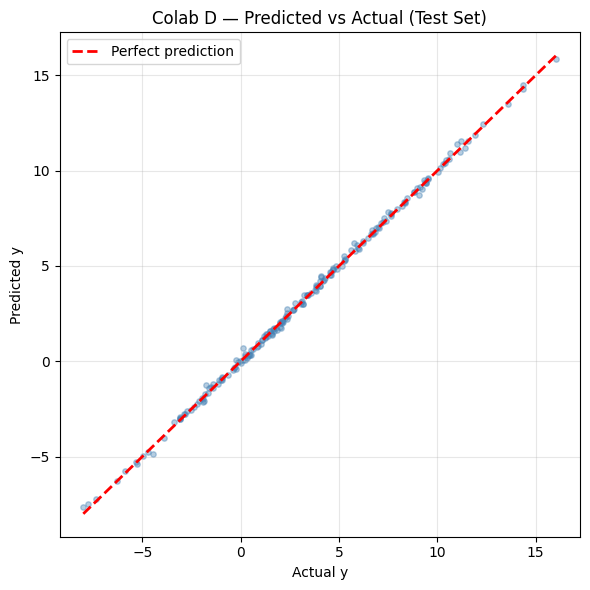

Test MSE : 0.0220
Test MAE : 0.1096
Stopped at epoch: 660


In [7]:
# ── Section 5: Results ────────────────────────────────────────────────
import pandas as pd, os

# Safe metrics loading — metrics.csv may not exist in all PL versions
log_dir = getattr(trainer.logger, 'log_dir', None)
csv_path = os.path.join(log_dir, 'metrics.csv') if log_dir else None

if csv_path and os.path.exists(csv_path):
    metrics = pd.read_csv(csv_path)
    # Plot train/val loss from CSV
    train_loss = metrics[metrics['train_loss'].notna()]['train_loss'].values
    val_loss   = metrics[metrics['val_loss'].notna()]['val_loss'].values
    plt.figure(figsize=(10,4))
    plt.semilogy(train_loss, label='Train Loss', color='steelblue')
    plt.semilogy(val_loss,   label='Val Loss',   color='red', linestyle='--')
    plt.xlabel('Step'); plt.ylabel('MSE Loss (log)')
    plt.title('Colab D — PyTorch Lightning Training Curves')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
else:
    # Fallback: print final logged metrics from trainer directly
    print('Final metrics:', trainer.callback_metrics)

# ── Predict on test set ───────────────────────────────────────────────
import numpy as np
model.eval()
X_te = torch.tensor(X_n[int(0.8*N):], dtype=torch.float32)
y_te = y_n[int(0.8*N):]

with torch.no_grad():
    yp = model(X_te).numpy() * y_std + y_mean
    yt = y_te * y_std + y_mean

plt.figure(figsize=(6,6))
plt.scatter(yt, yp, alpha=0.4, s=15, color='steelblue')
mn, mx = yt.min(), yt.max()
plt.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual y'); plt.ylabel('Predicted y')
plt.title('Colab D — Predicted vs Actual (Test Set)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'Test MSE : {((yp - yt)**2).mean():.4f}')
print(f'Test MAE : {np.abs(yp - yt).mean():.4f}')
print(f'Stopped at epoch: {trainer.current_epoch}')